# Replication file for India microfinance dataset

In [5]:
import pandas as pd
import scipy.io as scio
import numpy as np
from functions_india import *
# import data 
network = scio.loadmat("India_networks_wave2.mat")
# contents of network
network = network['Z'][0]
# each is a sparse network, transform it into a numpy matrix
covariates_full = pd.read_stata('India_covariates_wave2.dta')
covariates_list = []
network_favor_list = []
network_info_list = []
for i in range(len(network)):
    network_i = []
    for j in range(len(network[i][0])):
        if j != 11:
            network_i.append(network[i][0][j].toarray())
    # information network and favor network
    if (i != 12) & (i != 21):
        covariate_i = covariates_full[covariates_full['village'] == i+1]
        adjmatrix_key = covariate_i['vertex_w2'].values
        adjmatrix_key = (adjmatrix_key-1).astype(int)
        network_favor_i = ((network_i[5]+network_i[6])>0)
        network_favor_i = ((network_favor_i + network_favor_i.T)>0)
        network_favor_i = network_favor_i[adjmatrix_key,:][:,adjmatrix_key]
        network_favor_list.append(network_favor_i)
        network_info_i = ((network_i[10]+network_i[11])>0)
        network_info_i = ((network_info_i + network_info_i.T)>0)
        network_info_i = network_info_i[adjmatrix_key,:][:,adjmatrix_key]
        network_info_list.append((network_info_i))
        covariates_list.append(covariate_i)
# generate dyadic covariates
X_list = []
# we generate "same_caste" "room_no_diff", "same_electricity", "same_latrine", "same_ownrent", "leader_diff"
# First, we generate dyadic dataset for each village
variable_list = [ "Same caste",  "Same electricity", "Same latrine", "Same ownrent", "Bed number difference", "Room number difference"]
p = len(variable_list)
data = np.zeros((0, p+2))
for i in range(75):
    ni = network_favor_list[i].shape[0]
    Ni = ni*(ni-1)
    covariates_i = covariates_list[i]
    X = np.zeros((Ni, p))
    # Same caste
    count = 0
    Xmat = covariates_i['caste_group'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= ((Xmat_i == Xmat_j).astype(int)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    # same_electricity
    count += 1
    Xmat = covariates_i['electricity'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= ((Xmat_i == Xmat_j).astype(int)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    # same_latrine
    count += 1
    Xmat = covariates_i['latrine'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= ((Xmat_i == Xmat_j).astype(int)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    # same_ownrent
    count += 1
    Xmat = covariates_i['ownrent'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= ((Xmat_i == Xmat_j).astype(int)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    # Bed number difference
    count += 1
    Xmat = covariates_i['bed_no'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= (abs(Xmat_i - Xmat_j)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    # Room number difference
    count += 1
    Xmat = covariates_i['room_no'].values
    Xmat_i = np.repeat(Xmat, ni)
    Xmat_j = np.tile(Xmat, ni)
    A= (abs(Xmat_i - Xmat_j)).reshape(ni, ni)
    X[:,count] = A[np.where(np.eye(ni)==0)].reshape(Ni)
    link = np.zeros((Ni,2))
    link[:,0] = np.reshape(network_favor_list[i][np.where(np.eye(ni)==0)], (Ni,))
    link[:,1] = np.reshape(network_info_list[i][np.where(np.eye(ni)==0)], (Ni,))
    X_link = np.concatenate((link, X), axis = 1)
    data = np.concatenate((data, X_link), axis = 0)
    X_list.append(X)
# save the summary statistics, mean link, and network size
variable_list_summary = ["Information link", "Favor link", "Same caste",  "Same electricity", "Same latrine", "Same ownrent", "Bed number difference", "Room number difference"]
observation_number = np.repeat(np.shape(data)[0], np.shape(data)[1])/2
mean = np.mean(data, axis = 0)
std = np.std(data, axis = 0)
min = np.min(data, axis = 0)
max = np.max(data, axis = 0)
table = pd.DataFrame({'Variable':variable_list_summary, 'Obseravation':observation_number, 'Mean':mean, 'Standard deviation':std, 'Minimum':min, 'Maximum':max})

In [6]:
# beta estimation 
import warnings
warnings.filterwarnings("ignore")
BG_favor = []
sd_BG_favor = []
BG_info = []
sd_BG_info = []

for i in tqdm(range(75)):
    p = X_list[i].shape[1]
    beta0 = np.zeros(p)
    # if there is warning, we try different random seed
    try:
        np.random.seed(i)
        beta_mm_favor = est_beta_MM(X_list[i], network_favor_list[i], X_list[i], beta0, maxit = 1e4)
        beta_bg_favor = est_MLE_bagging(X_list[i], network_favor_list[i], beta_mm_favor, B=100)
        beta_mm_info = est_beta_MM(X_list[i], network_info_list[i], X_list[i], beta0, maxit = 1e4)
        beta_bg_info = est_MLE_bagging(X_list[i], network_info_list[i], beta_mm_info, B=100)
        
    except:
        np.random.seed(i+2023)
        beta_mm_favor = est_beta_MM(X_list[i], network_favor_list[i], X_list[i], beta0, maxit = 1e4)
        beta_bg_favor = est_MLE_bagging(X_list[i], network_favor_list[i], beta_mm_favor, B=100)
        beta_mm_info = est_beta_MM(X_list[i], network_info_list[i], X_list[i], beta0, maxit = 1e4)
        beta_bg_info = est_MLE_bagging(X_list[i], network_info_list[i], beta_mm_info, B=100)
    BG_favor.append(beta_bg_favor[0])
    sd_BG_favor.append(beta_bg_favor[1])
    BG_info.append(beta_bg_info[0])
    sd_BG_info.append(beta_bg_info[1])

100%|██████████| 75/75 [24:25<00:00, 19.54s/it]


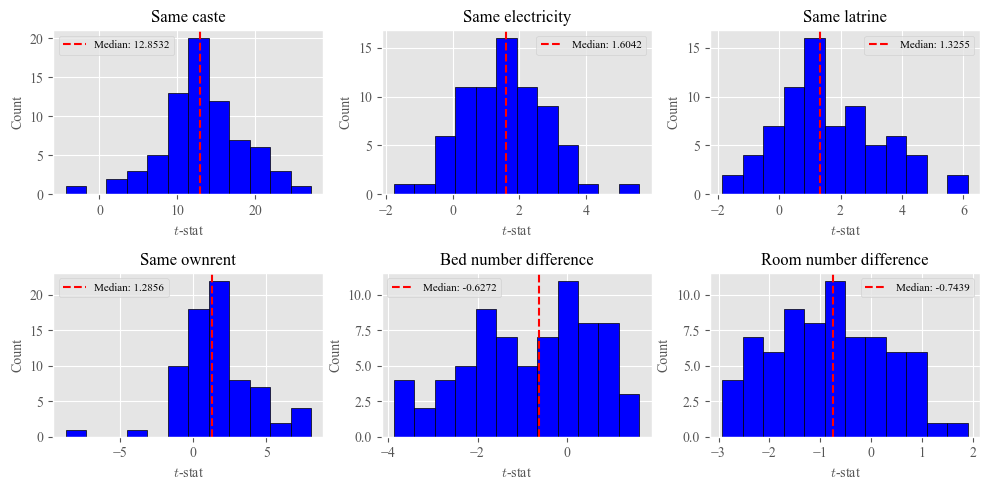

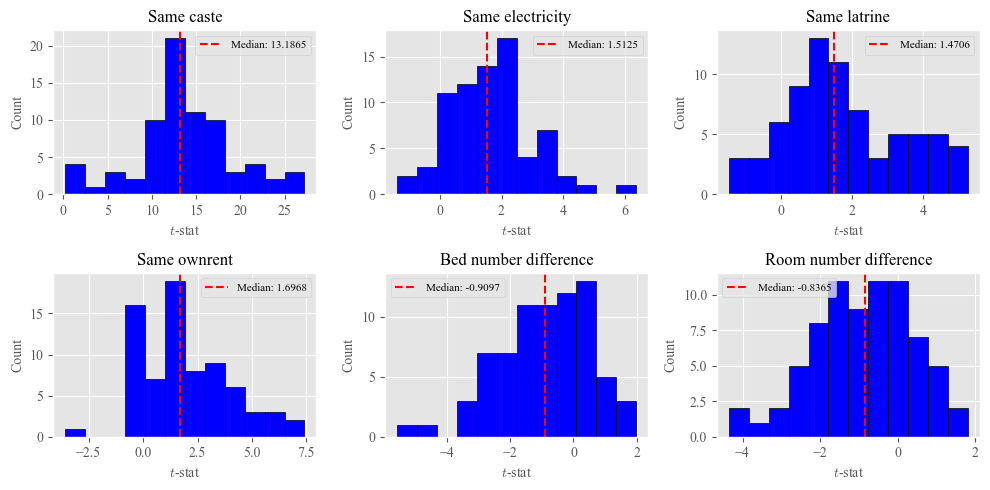

In [12]:
# plot the distribution of the estimated coefficients 
import matplotlib.pyplot as plt
# Set the style of the figure
plt.style.use('ggplot')  # Change to your desired style

# plot the t-stat histogram
plt.rcParams['font.family'] = 'Times New Roman'  # Change to your desired font family
plt.rcParams['font.size'] =  10  # Change to your desired font size
plt.rcParams['axes.titlesize'] = 12  # Change to your desired title font size
plt.rcParams['axes.labelsize'] = 10  # Change to your desired label font size
plt.rcParams['legend.fontsize'] = 8 # Change to your desired legend font size
plt.rcParams['xtick.labelsize'] = 10
# change the math font
plt.rcParams['mathtext.fontset'] = 'cm'

# for each covariate, plot the distribution of BG estimation, exclude these extreme values, info network
plt.figure(figsize=(10, 5))
p = 6
BG_matrix = np.vstack(BG_info)
sd_BG_matrix = np.vstack(sd_BG_info)
t_BG_matrix = BG_matrix/sd_BG_matrix

for j in range(p):
    plt.subplot(2, 3, j+1)
    t_BG_j= t_BG_matrix[:,j]
    # exclude na
    t_BG_j = t_BG_j[~np.isnan(t_BG_j)]
    # exclude the extreme values
    #t_BG_j = t_BG_j[np.where(abs(t_BG_j)<100)]
    plt.hist(t_BG_j, color='blue', bins=12, edgecolor='black')
    # plot the median value
    plt.axvline(x=np.median(t_BG_j), color='r', linestyle='--', label='Median: '+str(round(np.median(t_BG_j),4)))
    plt.title(variable_list[j])
    plt.xlabel('$t$-stat')
    plt.ylabel('Count')
    plt.legend()
plt.tight_layout()
plt.savefig('BG_t_stat_info.pdf')
plt.show()

# for each covariate, plot the distribution of BG estimation, exclude these extreme values, favor network
plt.figure(figsize=(10, 5))
p = 6
BG_matrix = np.vstack(BG_favor)
sd_BG_matrix = np.vstack(sd_BG_favor)
t_BG_matrix = BG_matrix/sd_BG_matrix

for j in range(p):
    plt.subplot(2, 3, j+1)
    t_BG_j= t_BG_matrix[:,j]
    # exclude na
    t_BG_j = t_BG_j[~np.isnan(t_BG_j)]
    # exclude the extreme values
    #t_BG_j = t_BG_j[np.where(abs(t_BG_j)<100)]
    plt.hist(t_BG_j, color='blue', bins=12, edgecolor='black')
    # plot the median value
    plt.axvline(x=np.median(t_BG_j), color='r', linestyle='--', label='Median: '+str(round(np.median(t_BG_j),4)))
    plt.title(variable_list[j])
    plt.xlabel('$t$-stat')
    plt.ylabel('Count')
    plt.legend()
plt.tight_layout()
plt.savefig('BG_t_stat_favor.pdf')
plt.show()

In [10]:
# alpha_fit 
alpha_fit_favor=[]
alpha_fit_info=[]   
for i in tqdm(range(75)):
    if (np.isnan(BG_favor[i]).any())|(np.isnan(X_list[i]).any()):
        continue
    alpha_mm = alpha_MM(BG_favor[i], X_list[i], network_favor_list[i], tol = 1e-3, maxit = 1e4)
    alpha_fit_favor.append(alpha_mm)
    alpha_mm = alpha_MM(BG_info[i], X_list[i], network_info_list[i], tol = 1e-3, maxit = 1e4)
    alpha_fit_info.append(alpha_mm)


100%|██████████| 75/75 [04:28<00:00,  3.58s/it]


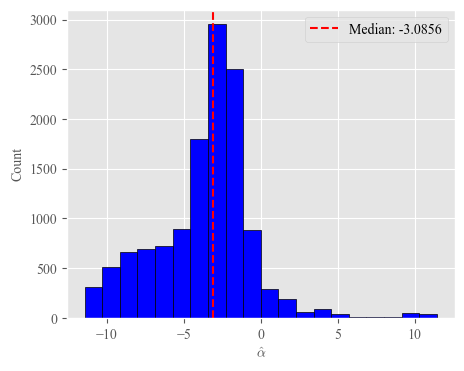

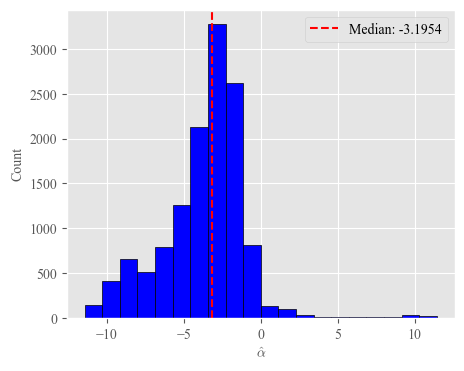

In [13]:
alpha_fit_array = np.hstack(alpha_fit_info)
# delete nan values
alpha_fit_array = alpha_fit_array[~np.isnan(alpha_fit_array)]
plt.rcParams['legend.fontsize'] = 10
# look at what value is na
#print(np.where(np.isnan(alpha_fit_array)))
plt.figure(figsize=(5, 4))
plt.hist(alpha_fit_array, color='blue', bins=20, edgecolor='black')
plt.axvline(x=np.median(alpha_fit_array), color='r', linestyle='--', label='Median: '+str(round(np.median(alpha_fit_array),4)))
plt.xlabel('$\\hat\\alpha$')
plt.ylabel('Count')
plt.legend()
plt.savefig('alpha_fit_indian_info.pdf')
plt.show()

alpha_fit_array = np.hstack(alpha_fit_favor)
# delete nan values
alpha_fit_array = alpha_fit_array[~np.isnan(alpha_fit_array)]
plt.rcParams['legend.fontsize'] = 10
# look at what value is na
#print(np.where(np.isnan(alpha_fit_array)))
plt.figure(figsize=(5, 4))
plt.hist(alpha_fit_array, color='blue', bins=20, edgecolor='black')
plt.axvline(x=np.median(alpha_fit_array), color='r', linestyle='--', label='Median: '+str(round(np.median(alpha_fit_array),4)))
plt.xlabel('$\\hat\\alpha$')
plt.ylabel('Count')
plt.legend()
plt.savefig('alpha_fit_indian_favor.pdf')
plt.show()